## Netflix Content Strategy Analysis

This notebook analyzes 8,807 Netflix titles to understand how Netflix's content 
strategy has evolved over time — content type balance, geographic production, 
volume growth, and genre trends.

**Questions this analysis answers:**
1. What type of content dominates, and has this changed over time?
2. Which countries produce the most content?
3. How has content volume changed over time?
4. What genres are most common?

## 1. Load & Inspect Data

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

df = pd.read_csv("/Users/hazeezatadebayo/Downloads/netflix_titles.csv")

print(df.shape)
print(df.columns.tolist())
print(df.dtypes)
df.head()

(8807, 12)
['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added', 'release_year', 'rating', 'duration', 'listed_in', 'description']
show_id         object
type            object
title           object
director        object
cast            object
country         object
date_added      object
release_year     int64
rating          object
duration        object
listed_in       object
description     object
dtype: object


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


## 2. Check Missing Values

Before cleaning anything, check what's actually missing and why — 
missing values should be handled deliberately, not automatically dropped.

In [3]:
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print(missing)

director      2634
country        831
cast           825
date_added      10
rating           4
duration         3
dtype: int64


## 3. Data Cleaning

### 3.1 Convert `date_added` to datetime and extract year

In [4]:
df_clean = df.copy()

df_clean['date_added'] = pd.to_datetime(
    df_clean['date_added'].str.strip(),
    errors='coerce'
)

df_clean['year_added'] = df_clean['date_added'].dt.year

### 3.2 Extract primary country

`country` is comma-separated for multi-country productions. 
Using the first-listed country as a simplified "primary" country for ranking.

In [5]:
df_clean['primary_country'] = (
    df_clean['country']
    .str.split(',')
    .str[0]
    .str.strip()
)

### 3.3 Handle remaining missing values

`director` and `cast` aren't used in this analysis but are filled for completeness.
`country`/`primary_country` missing values are labeled "Unknown" and excluded 
from country-specific charts later, to avoid misleadingly ranking "Unknown" 
as a top producer.

Rows missing `rating`, `duration`, or `date_added` are dropped — a negligible 
17 rows out of 8,807.

In [6]:
df_clean['director'] = df_clean['director'].fillna('Unknown')
df_clean['cast'] = df_clean['cast'].fillna('Unknown')
df_clean['country'] = df_clean['country'].fillna('Unknown')
df_clean['primary_country'] = df_clean['primary_country'].fillna('Unknown')

df_clean = df_clean.dropna(subset=['rating', 'duration', 'date_added'])

print("Before:", df.shape)
print("After:", df_clean.shape)

Before: (8807, 12)
After: (8790, 14)


### 3.4 Sanity check

In [7]:
df_clean[['type', 'primary_country', 'listed_in', 'year_added']].head(10)

,type,primary_country,listed_in,year_added
0,Movie,United States,Documentaries,2021.0
1,TV Show,South Africa,"International TV Shows, TV Dramas, TV Mysteries",2021.0
2,TV Show,Unknown,"Crime TV Shows, International TV Shows, TV Act...",2021.0
3,TV Show,Unknown,"Docuseries, Reality TV",2021.0
4,TV Show,India,"International TV Shows, Romantic TV Shows, TV ...",2021.0
5,TV Show,Unknown,"TV Dramas, TV Horror, TV Mysteries",2021.0
6,Movie,Unknown,Children & Family Movies,2021.0
7,Movie,United States,"Dramas, Independent Movies, International Movies",2021.0
8,TV Show,United Kingdom,"British TV Shows, Reality TV",2021.0
9,Movie,United States,"Comedies, Dramas",2021.0


### 3.5 Data quality check — duplicates

In [8]:
print("Duplicate show_ids:", df_clean.duplicated(subset=['show_id']).sum())

Duplicate show_ids: 0


## Q1 — What type of content dominates, and has this changed over time?

In [9]:
print(df_clean['type'].value_counts(normalize=True))

type_by_year = df_clean.groupby(['year_added', 'type']).size().unstack(fill_value=0)
type_by_year_pct = type_by_year.div(type_by_year.sum(axis=1), axis=0) * 100
print(type_by_year_pct.round(1))

Movie      0.696928
TV Show    0.303072
Name: type, dtype: float64
type        Movie  TV Show
year_added                
2008.0       50.0     50.0
2009.0      100.0      0.0
2010.0      100.0      0.0
2011.0      100.0      0.0
2012.0      100.0      0.0
2013.0       54.5     45.5
2014.0       79.2     20.8
2015.0       68.3     31.7
2016.0       58.9     41.1
2017.0       70.5     29.5
2018.0       75.1     24.9
2019.0       70.6     29.4
2020.0       68.3     31.7
2021.0       66.3     33.7


**Finding:** Movies make up ~69.7% of the catalog overall, but their yearly 
share declined from 75% (2018) to 66% (2021), with TV Shows rising 
correspondingly — a gradual but real strategic shift.

*Note: 2008–2012 excluded from this trend due to very small sample sizes 
(1–2 titles per year) that make percentages unreliable.*

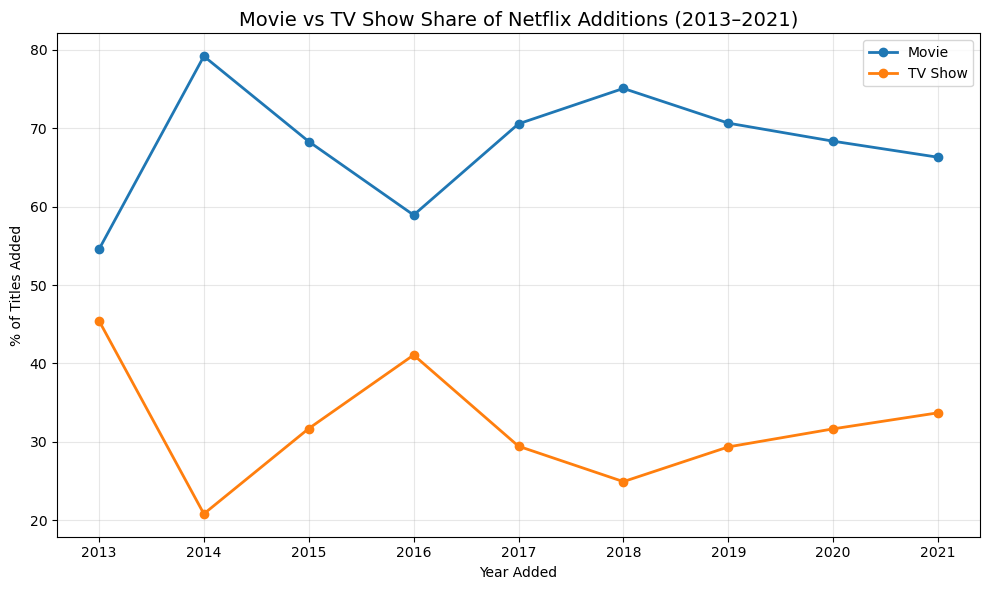

In [10]:
chart_data = type_by_year_pct.loc[2013:2021]

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(chart_data.index, chart_data['Movie'], marker='o', label='Movie', linewidth=2)
ax.plot(chart_data.index, chart_data['TV Show'], marker='o', label='TV Show', linewidth=2)

ax.set_title('Movie vs TV Show Share of Netflix Additions (2013–2021)', fontsize=14)
ax.set_xlabel('Year Added')
ax.set_ylabel('% of Titles Added')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('q1_movie_vs_tv_trend.png', dpi=150)
plt.show()

## Q2 — Which countries produce the most content?

"Unknown" (missing country data, ~9% of titles) is excluded from this 
ranking to avoid misrepresenting missing data as a top producer.

In [11]:
top_countries = df_clean[df_clean['primary_country'] != 'Unknown']['primary_country'].value_counts().head(10)
print(top_countries)

United States     3202
India             1008
United Kingdom     627
Canada             271
Japan              257
France             212
South Korea        211
Spain              181
Mexico             134
Australia          115
Name: primary_country, dtype: int64


**Finding:** The United States (3,202 titles) and India (1,008) lead 
production by a wide margin; the UK is a distant third (627).

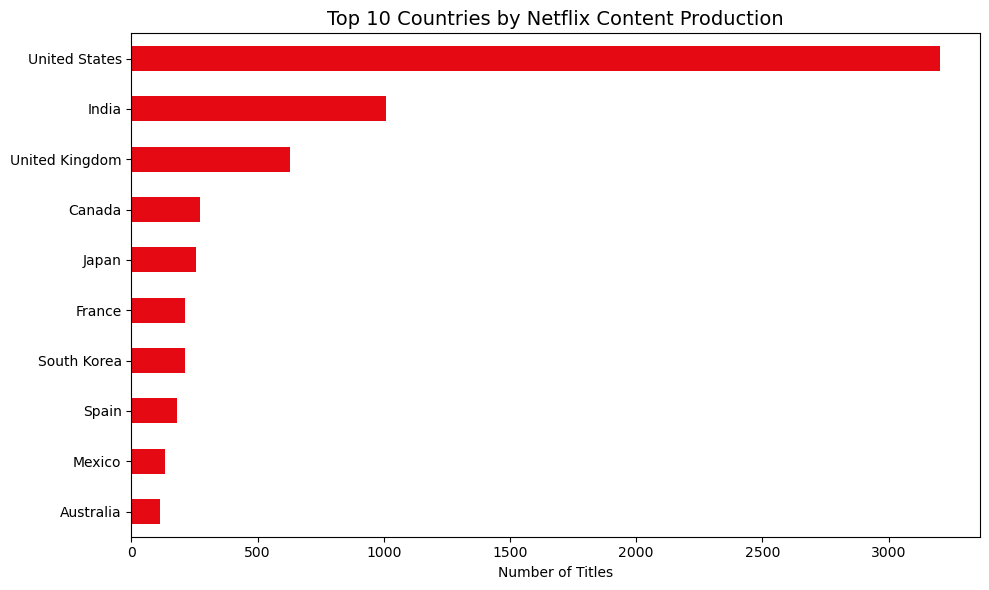

In [12]:
fig, ax = plt.subplots(figsize=(10, 6))
top_countries.sort_values().plot(kind='barh', ax=ax, color='#E50914')

ax.set_title('Top 10 Countries by Netflix Content Production', fontsize=14)
ax.set_xlabel('Number of Titles')
ax.set_ylabel('')

plt.tight_layout()
plt.savefig('q2_top_countries.png', dpi=150)
plt.show()

In [21]:
# Top 3 countries' share of additions, year by year
top3 = ['United States', 'India', 'United Kingdom']
country_by_year = df_clean[df_clean['primary_country'].isin(top3) & df_clean['year_added'].between(2013, 2021)]
country_trend = country_by_year.groupby(['year_added', 'primary_country']).size().unstack(fill_value=0)
country_trend_pct = country_trend.div(country_trend.sum(axis=1), axis=0) * 100
print(country_trend_pct.round(1))

primary_country  India  United Kingdom  United States
year_added                                           
2013.0             0.0             0.0          100.0
2014.0             0.0            13.6           86.4
2015.0             0.0             6.9           93.1
2016.0             4.7            19.3           76.0
2017.0            22.6            17.8           59.6
2018.0            35.4            12.1           52.5
2019.0            18.7            13.7           67.7
2020.0            19.1            10.6           70.3
2021.0            13.9            10.7           75.3


## Q3 — How has content volume changed over time?

In [14]:
year_counts = df_clean['year_added'].value_counts().sort_index()
print(year_counts)

2008.0       2
2009.0       2
2010.0       1
2011.0      13
2012.0       3
2013.0      11
2014.0      24
2015.0      82
2016.0     426
2017.0    1185
2018.0    1648
2019.0    2016
2020.0    1879
2021.0    1498
Name: year_added, dtype: int64


**Finding:** Content additions grew sharply from 2016–2019, peaking at 
2,016 titles in 2019. 2021 shows a lower volume of additions, likely 
influenced by incomplete-year data (this dataset was collected mid-2021) 
rather than an actual pullback.

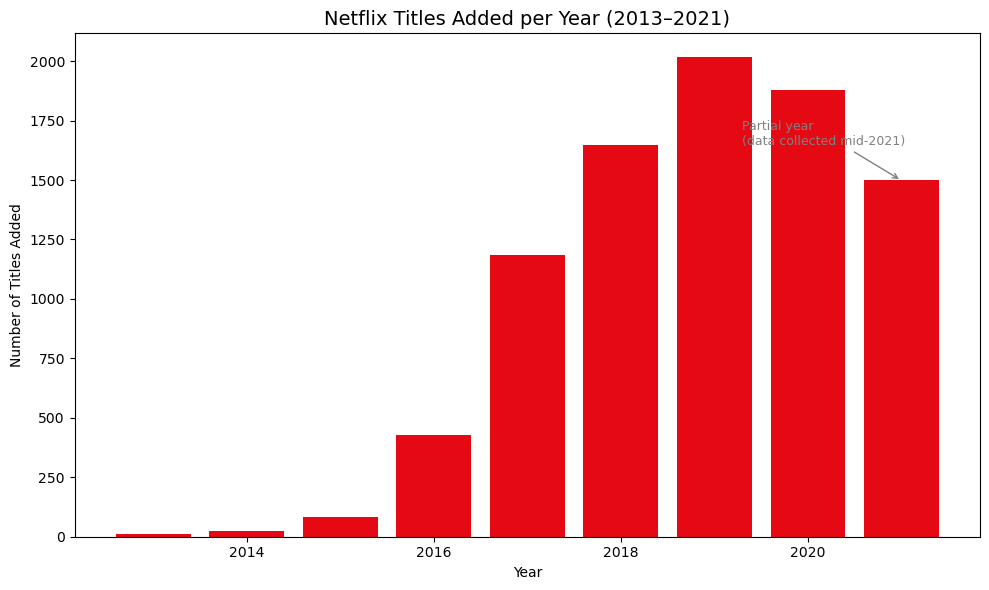

In [15]:
reliable_years = year_counts.loc[2013:2021]

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(reliable_years.index, reliable_years.values, color='#E50914')

ax.set_title('Netflix Titles Added per Year (2013–2021)', fontsize=14)
ax.set_xlabel('Year')
ax.set_ylabel('Number of Titles Added')
ax.annotate('Partial year\n(data collected mid-2021)',
            xy=(2021, reliable_years[2021]),
            xytext=(2019.3, reliable_years[2021]+150),
            fontsize=9, color='gray',
            arrowprops=dict(arrowstyle='->', color='grey'))

plt.tight_layout()
plt.savefig('q3_titles_per_year.png', dpi=150)
plt.show()

## Q4 — What genres are most common?

`listed_in` contains multiple comma-separated genres per title, 
so it's split and exploded before counting.

In [16]:
all_genres = df_clean['listed_in'].str.split(',').explode().str.strip()
genre_counts = Counter(all_genres)

for genre, count in genre_counts.most_common(15):
    print(f"{count:5d}  {genre}")

 2752  International Movies
 2426  Dramas
 1674  Comedies
 1349  International TV Shows
  869  Documentaries
  859  Action & Adventure
  762  TV Dramas
  756  Independent Movies
  641  Children & Family Movies
  616  Romantic Movies
  577  Thrillers
  573  TV Comedies
  469  Crime TV Shows
  448  Kids' TV
  394  Docuseries


**Finding:** International Movies (2,752) and Dramas (2,426) are the most 
common genres, well ahead of Comedies (1,674) — reflecting Netflix's 
global-content strategy.

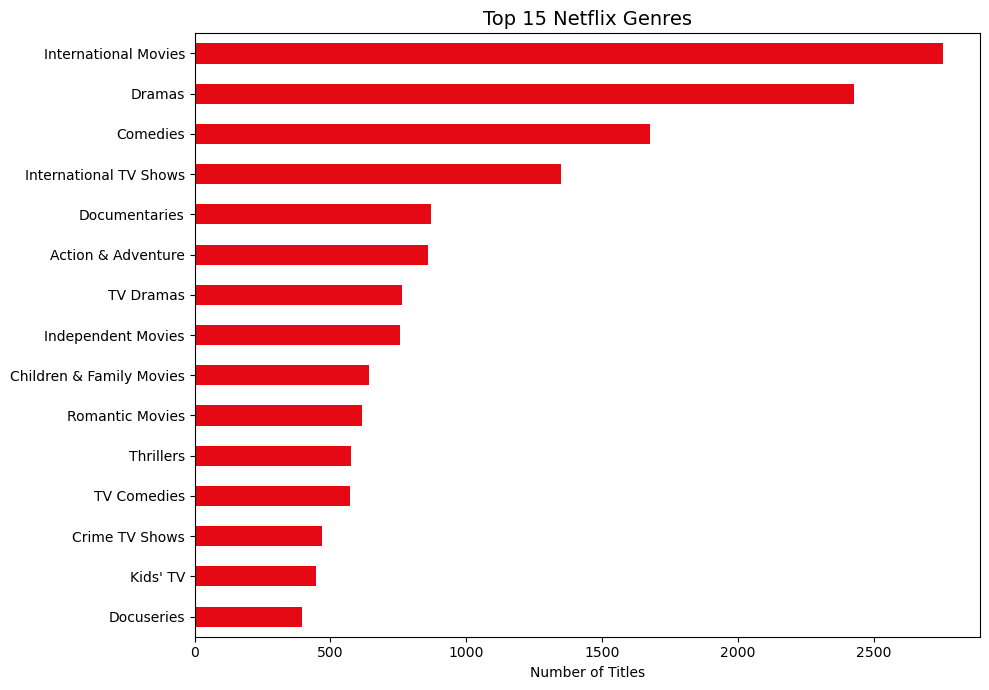

In [17]:
top_genres = pd.Series(dict(genre_counts.most_common(15))).sort_values()

fig, ax = plt.subplots(figsize=(10, 7))
top_genres.plot(kind='barh', ax=ax, color='#E50914')

ax.set_title('Top 15 Netflix Genres', fontsize=14)
ax.set_xlabel('Number of Titles')
ax.set_ylabel('')

plt.tight_layout()
plt.savefig('q4_top_genres.png', dpi=150)
plt.show()

In [22]:
# Top genres for international content only
intl_genres = df_clean[df_clean['is_domestic'] == False]
intl_genre_exploded = intl_genres['listed_in'].str.split(',').explode().str.strip()
intl_genre_counts = Counter(intl_genre_exploded)

for genre, count in intl_genre_counts.most_common(10):
    print(f"{count:5d}  {genre}")

 2706  International Movies
 1752  Dramas
 1307  International TV Shows
 1064  Comedies
  557  TV Dramas
  536  Action & Adventure
  425  Independent Movies
  421  Romantic Movies
  416  Documentaries
  348  Crime TV Shows


## Bonus — International vs. Domestic (US) Share Over Time

While researching country trends, an additional pattern emerged worth 
verifying: has international content's *share* of the catalog grown 
over time, not just its raw count?

In [18]:
df_clean['is_domestic'] = df_clean['primary_country'] == 'United States'

intl_by_year = df_clean[df_clean['year_added'].between(2013, 2021)].groupby(
    ['year_added', 'is_domestic']
).size().unstack(fill_value=0)
intl_by_year.columns = ['International', 'Domestic (US)']
intl_by_year_pct = intl_by_year.div(intl_by_year.sum(axis=1), axis=0) * 100

print(intl_by_year_pct.round(1))

            International  Domestic (US)
year_added                              
2013.0                9.1           90.9
2014.0               20.8           79.2
2015.0               34.1           65.9
2016.0               58.5           41.5
2017.0               66.0           34.0
2018.0               69.5           30.5
2019.0               61.9           38.1
2020.0               62.2           37.8
2021.0               64.0           36.0


**Finding:** International content's share of yearly additions grew from 
just 9.1% in 2013 to consistently 60–70% from 2016 onward — a substantial, 
verified shift toward global content, not just a byproduct of overall growth.

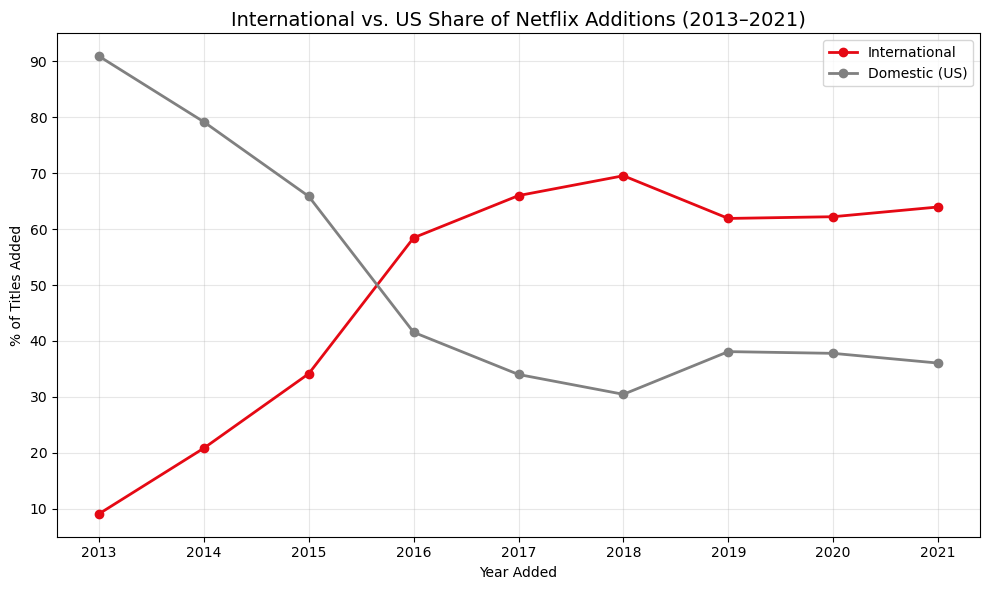

In [19]:
fig, ax = plt.subplots(figsize=(10, 6))
chart_data = intl_by_year_pct.loc[2013:2021]
ax.plot(chart_data.index, chart_data['International'], marker='o', linewidth=2, color='#E50914', label='International')
ax.plot(chart_data.index, chart_data['Domestic (US)'], marker='o', linewidth=2, color='gray', label='Domestic (US)')

ax.set_title('International vs. US Share of Netflix Additions (2013–2021)', fontsize=14)
ax.set_xlabel('Year Added')
ax.set_ylabel('% of Titles Added')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('q_bonus_international_trend.png', dpi=150)
plt.show()

In [20]:
# Content type split: International vs Domestic
type_by_origin = df_clean.groupby(['is_domestic', 'type']).size().unstack(fill_value=0)
type_by_origin_pct = type_by_origin.div(type_by_origin.sum(axis=1), axis=0) * 100
type_by_origin_pct.index = ['International', 'Domestic (US)']
print(type_by_origin_pct.round(1))

type           Movie  TV Show
International   67.4     32.6
Domestic (US)   73.7     26.3


## Export for Tableau

In [56]:
tableau_export = df_clean[[
    'show_id', 'type', 'title', 'primary_country', 'country',
    'date_added', 'year_added', 'release_year', 'rating',
    'duration', 'listed_in'
]].copy()
tableau_export.to_csv('netflix_clean_for_tableau.csv', index=False)

genre_exploded = df_clean[['show_id', 'type', 'primary_country', 'year_added', 'listed_in']].copy()
genre_exploded['listed_in'] = genre_exploded['listed_in'].str.split(',')
genre_exploded = genre_exploded.explode('listed_in')
genre_exploded['listed_in'] = genre_exploded['listed_in'].str.strip()
genre_exploded.to_csv('netflix_genres_exploded.csv', index=False)

print("Exported:", tableau_export.shape, genre_exploded.shape)

Exported: (8790, 11) (19294, 5)
